# SISE ion-flux software (Ahmad et al. 2025) — ADAPTED PYTHON DEMONSTRATION

**Paper:** Ahmad N, Tennakoon K, Hedrich R, Huang S, Roelfsema MRG (2025). *SISE, free LabView-based software for ion flux measurements.* Plant Methods 21:152. https://doi.org/10.1186/s13007-025-01448-8 (PMC12628975, CC BY)

**Author code:** https://github.com/Rob-Roelfsema/SISE-Software-April2025 @ `1773ba9356b796d4095ef2ac7af1196db1d4e709` (CC0-1.0)

**Scope (partial demonstration):** Reimplementation of the documented SISE-Analyser110 analysis pipeline — drift-corrected dV, Nernst calibration, cylinder geometry correction, chemical-potential (Newman 2001) and diffusion-gradient (Fick) K+ flux calculation — executed on a **synthetic** SISE-Monitor-format ASCII recording that emulates the barley-root experiment of Figs. 5–7 (0.5 mM K+ + 0.1 mM Ca2+, 100 mM NaCl added at 10 min).

**Execution status:** EXECUTED (CPU). Not a verification of the authors' recorded data.

**⚠ AI-assisted translation:** The authors' programs are LabView virtual instruments (.vi) and Windows executables that require NI LabView 2025Q1 on Windows; they cannot run in this Linux Colab runtime. This notebook is an **AI-assisted Python port** of the documented calculation; the authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed. The published equations (Figs/Eq 1–4) are embedded as images and could not be read under the text-only policy; the formulas here are reconstructed from the paper's text, its supplementary manual, and the cited method literature (Newman 2001; Smith et al. 1994; Arif et al. 1995), and are self-consistency-checked against the paper's narrative (Fig. 7).

**日本語要約:** 著者のSISEソフトウェアはWindows+LabView専用のため、本ノートブックは論文に記載された解析手順（ドリフト補正dV、検量線、円柱幾何補正、化学ポテンシャル法および拡散勾配法によるK+フラックス計算）をAIがPythonへ翻訳し、合成データで実行する**部分的なデモンストレーション**です。著者提供の実測データファイル（TestData-BarleyRoot.txt）は公開補足資料に含まれておらず、本実行は論文結果の検証ではありません。

**Runtime:** CPU only (Colab → Runtime → Change runtime type → CPU). No GPU is used by this method. Expected duration: < 2 minutes; no downloads.

In [ ]:
import sys, platform
print("python:", sys.version)
try:
    import numpy, matplotlib
    print("numpy", numpy.__version__, "| matplotlib", matplotlib.__version__)
except ImportError as e:
    raise RuntimeError(f"Missing dependency: {e} — install with pip in a cell above this point.")

python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
numpy 2.1.3 | matplotlib 3.10.0


## 1. Scope, evidence base, and what is NOT reproduced

| Paper element | This notebook |
|---|---|
| SISE-Monitor hardware recording (Patchstar + NI A/D, 10 ms loop) | Emulated: synthetic ASCII file in the documented SISE-Monitor format (10 ms sampling, 1000 points per position loop) |
| SISE-Analyser110 "View data" module | Reimplemented: file parsing, position/voltage preview |
| Drift-corrected dV via parallel regression lines | Reimplemented (same algorithm) |
| "Calibration" module (chemical potential / diffusion gradient, geometry) | Reimplemented with the paper's Tab. S3 calibration values and geometry |
| Buffer correction (Arif 1995) | **Out of scope** — applies to H+ fluxes; the demonstration ion is K+ |
| TestData-BarleyRoot.txt | **Unavailable**: promised in supplement part 4 but absent from the deposited supplement and the GitHub repo — synthetic data are used instead |

Evidence base: paper full text (Europe PMC XML), supplementary manual (text extraction), author repo tree at the pinned commit.

## 2. Synthetic SISE-Monitor-format recording

**Explanation:** We generate a tab-separated ASCII file following the documented SISE-Monitor data-file layout (supplement Fig. S2 description: first row = parameters chosen at initiation, second row = value indicators, following lines = data; stored every ~10 ms; the electrode alternates between position 0 and 1, 1000 datapoints per position loop). The synthetic experiment mimics the paper's barley demo: K+ electrode at 50 µm (position 0) and 100 µm (position 1) from the root surface, 0.5 mM K+ background, and a NaCl-elicited K+ efflux transient after 10 min. A slow electrode drift is included so that the drift-correction step is exercised. The data are **clearly synthetic** — generated here, not measured.

**期待結果:** 論文記載のSISE-Monitor形式に従う合成ASCIIデータ（10 ms間隔、位置0/1交互、10分後にNaCl添加によるK+排出過渡応答、徐変ドリフト付き）が `/content/sise_demo_recording.txt` として作成される。

In [ ]:
import numpy as np

rng = np.random.default_rng(20251006)  # deterministic seed

# --- documented acquisition parameters (paper: Fig. 1 caption, monitor setup phase) ---
DT_S = 0.010                 # 10 ms sampling interval (SISE-Monitor110)
POINTS_PER_POSITION = 1000   # 1000 datapoints per position loop (~10 s per position)
SCAN_DISTANCE_UM = 50.0      # electrode moves 50 um between position 0 and 1
POS0_DIST_UM = 50.0          # position 0 is 50 um from the root surface (supplement part 4)
TOTAL_MINUTES = 30.0

# --- electrode calibration (paper supplement Table S3) ---
cal_c_mM = np.array([10.0, 1.0, 0.1])
cal_v_mV = np.array([53.0, 4.0, -49.0])
SLOPE_MV_DECADE, INTERCEPT_MV = np.polyfit(np.log10(cal_c_mM), cal_v_mV, 1)
print(f"Nernst calibration: V = {SLOPE_MV_DECADE:.2f} mV/decade * log10(C/mM) + {INTERCEPT_MV:.2f} mV")

# --- synthetic efflux transient (paper Fig. 7 shape: K+ efflux burst after NaCl at t=10 min) ---
def efflux_density(t_s):
    # nmol m-2 s-1, positive = efflux (out of the root); 0 before NaCl, transient peak ~ 250
    tc = (t_s - 600.0) / 120.0
    return np.where(tc > 0, 5000.0 * tc * np.exp(1.0 - tc), 0.0)

D_K = 1.96e-9           # K+ diffusion coefficient, m2/s (supplement Table S1)
DX_EFF_UM = 500.0 * np.log((500.0 + 100.0) / (500.0 + 50.0))  # cylinder-corrected distance (section 4)
dx_eff_m = DX_EFF_UM * 1e-6

# concentration at each electrode position implied by the transient efflux
t_axis = np.arange(0.0, TOTAL_MINUTES * 60.0, DT_S)
J_t = efflux_density(t_axis)                    # nmol m-2 s-1
dC_t = (J_t * 1e-9) * dx_eff_m / D_K            # mM (1 mM == 1 mol m-3)
C_bulk = 0.5                                    # mM K+ background (1 mM == 1 mol m-3)
C1_t = np.full_like(t_axis, C_bulk)             # far position ~= bulk
C0_t = C1_t + dC_t                              # near position sees higher K+

# electrode voltages with slow drift + noise; position loop structure
n_points = len(t_axis)
loops = n_points // POINTS_PER_POSITION
position_um = np.where((np.arange(n_points) // POINTS_PER_POSITION) % 2 == 0, POS0_DIST_UM, POS0_DIST_UM + SCAN_DISTANCE_UM)
at_pos0 = position_um == POS0_DIST_UM
C_at_electrode = np.where(at_pos0, C0_t, C1_t)
drift_mV = 0.35 * t_axis / 600.0                                  # slow electrode drift (mV)
V_mV = SLOPE_MV_DECADE * np.log10(C_at_electrode) + INTERCEPT_MV + drift_mV + rng.normal(0, 0.02, n_points)

# event marks in the documented "Event Mark" list style
marks = {600.0: "Added 100 mM NaCl"}

with open("/content/sise_demo_recording.txt", "w") as f:
    f.write("SISE-Monitor110-Demo\tscan=50\tangle=0\tperiod=10ms\tchannels=SISE1,V1\n")
    f.write("time_s\tposition_um\tSISE1_mV\tEvent_Mark\n")
    mark_i = 0
    mark_times = sorted(marks)
    for i in range(n_points):
        ev = ""
        if mark_i < len(mark_times) and t_axis[i] >= mark_times[mark_i]:
            ev = marks[mark_times[mark_i]]; mark_i += 1
        f.write(f"{t_axis[i]*1000:.0f}\t{position_um[i]:.0f}\t{V_mV[i]:.4f}\t{ev}\n")
print(f"wrote /content/sise_demo_recording.txt: {n_points} samples, {loops} position loops, "
      f"{TOTAL_MINUTES:.0f} min; synthetic (seed 20251006)")

Nernst calibration: V = 51.00 mV/decade * log10(C/mM) + 2.67 mV


wrote /content/sise_demo_recording.txt: 180000 samples, 180 position loops, 30 min; synthetic (seed 20251006)


## 3. Load the recording (SISE-Analyser "View data" role)

**Explanation:** The SISE-Analyser's first module loads the raw SISE-Monitor file and recovers per-measurement voltage statistics. We parse the tab-separated file and group the samples into measurements (each position loop = one measurement at one position), exactly as the "view data" window reports measurements sequentially.

**期待結果:** 全サンプルが測定（位置ループ）単位に分组され、測定数と各測定の時間・位置・平均電圧が表示される。

In [ ]:
import pandas as pd

raw = pd.read_csv("/content/sise_demo_recording.txt", sep="\t", skiprows=2,
                  names=["time_ms", "position_um", "SISE1_mV", "Event_Mark"],
                  dtype={"Event_Mark": "string"})
raw["time_s"] = raw["time_ms"] / 1000.0
raw["measurement"] = raw.index // POINTS_PER_POSITION

meas = (raw.groupby("measurement")
          .agg(t_s=("time_s", "mean"), position_um=("position_um", "mean"),
               V_mV=("SISE1_mV", "mean"), V_sd_mV=("SISE1_mV", "std"),
               n=("SISE1_mV", "size")))
print(f"{len(meas)} measurements loaded (paper Fig. 5 'View data' equivalent)")
print(meas.head(4).to_string(float_format=lambda v: f"{v:.3f}"))
assert meas["n"].eq(POINTS_PER_POSITION).all(), "unexpected loop length"
assert set(meas.position_um.round(0)) == {POS0_DIST_UM, POS0_DIST_UM + SCAN_DISTANCE_UM}

180 measurements loaded (paper Fig. 5 'View data' equivalent)
               t_s  position_um    V_mV  V_sd_mV     n
measurement                                           
0            4.995       50.000 -12.683    0.020  1000
1           14.995      100.000 -12.677    0.020  1000
2           24.995       50.000 -12.671    0.021  1000
3           34.995      100.000 -12.666    0.020  1000


**Explanation:** Input preview (required before any analysis): plot the electrode position and the raw voltage channel against time, in the style of the paper's Fig. 4/Fig. 5 middle graphs, marking the NaCl event.

**期待結果:** 位置ステップ（50 µm/100 µm交互）とNaCl添加後に上昇する電圧信号が描画される。

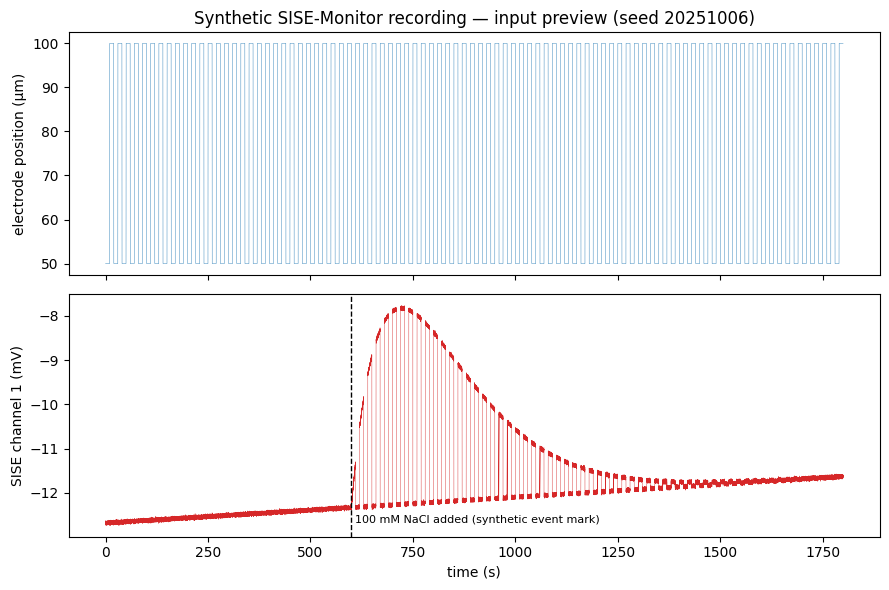

In [ ]:
import matplotlib.pyplot as plt  # inline backend renders figures into the notebook outputs

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(raw.time_s, raw.position_um, lw=0.3)
ax[0].set_ylabel("electrode position (µm)"); ax[0].set_title("Synthetic SISE-Monitor recording — input preview (seed 20251006)")
ax[1].plot(raw.time_s, raw.SISE1_mV, lw=0.3, color="tab:red")
ax[1].axvline(600, ls="--", color="k", lw=1); ax[1].text(610, ax[1].get_ylim()[0]+0.3, "100 mM NaCl added (synthetic event mark)", fontsize=8)
ax[1].set_ylabel("SISE channel 1 (mV)"); ax[1].set_xlabel("time (s)")
fig.tight_layout(); fig.savefig("/content/input_preview.png", dpi=120); plt.show()

## 4. Drift-corrected dV (parallel regression lines)

**Explanation:** Core SISE method: the differential voltage dV = V(position 0) − V(position 1) is obtained from the last three measurements. A regression line is fitted through the two most recent measurements at one position, and a parallel line (same slope) is fitted through the middle measurement at the other position; dV is the vertical distance between the two lines (paper: "the dV value can be deduced from the distance along the Y-Axis between both regression lines"). This compensates slow electrode drift, which is why we included drift in the synthetic data. The "start fit" fraction selects the tail portion of each 1000-point measurement used for fitting (paper's start-fit slider); we use the last 50%.

**期待結果:** 各測定三つ組ごとにdV系列が計算され、ドリフト（0.35 mV/10 min）が低減される。最初のdVは3測定を要するため遅れて現れる。

In [ ]:
START_FIT_FRACTION = 0.5  # tail fraction of each measurement used for the fit ("start fit" slider)

def measurement_fit_slice(g):
    n = len(g)
    return g.iloc[int(n * (1 - START_FIT_FRACTION)):]

rows = []
mids = meas.index.to_numpy()
for k in range(len(mids) - 2):
    a, b, c = mids[k], mids[k + 1], mids[k + 2]  # three consecutive measurements (positions alternate)
    trio = meas.loc[[a, b, c]]
    if trio.position_um.nunique() != 2:
        continue
    p0 = trio.index[trio.position_um == POS0_DIST_UM]
    p1 = trio.index[trio.position_um == POS0_DIST_UM + SCAN_DISTANCE_UM]
    # fit line through the LAST two measurements; parallel line through the middle one;
    # dV is always V(position 0) - V(position 1) evaluated at the middle measurement time
    if len(p0) == 1 and len(p1) == 2:
        fit_idx, par_idx, sign = [p1[0], p1[1]], [p0[0]], +1.0   # dV = V0 - V1(pos-line)
    elif len(p1) == 1 and len(p0) == 2:
        fit_idx, par_idx, sign = [p0[0], p0[1]], [p1[0]], -1.0   # dV = V0(pos-line) - V1
    else:
        continue
    xs = meas.loc[fit_idx, "t_s"].to_numpy(); ys = meas.loc[fit_idx, "V_mV"].to_numpy()
    slope = (ys[-1] - ys[0]) / (xs[-1] - xs[0])
    t_ref = meas.loc[par_idx[0], "t_s"]
    y_line_fit_at_ref = ys[0] + slope * (t_ref - xs[0])
    dV = sign * (meas.loc[par_idx[0], "V_mV"] - y_line_fit_at_ref)
    rows.append({"measurement": c, "t_s": meas.loc[c, "t_s"], "dV_mV": dV})

dV_df = pd.DataFrame(rows)
print(f"dV series: {len(dV_df)} values (first dV appears after 3 measurements, as in the paper)")
print(dV_df.head(3).to_string(float_format=lambda v: f"{v:.4f}"))
print("dV before NaCl (first 10):", dV_df.dV_mV.head(10).round(3).to_list())
print("max dV after NaCl:", round(dV_df.loc[dV_df.t_s > 600, 'dV_mV'].max(), 3), "mV")

dV series: 178 values (first dV appears after 3 measurements, as in the paper)
   measurement     t_s  dV_mV
0            2 24.9950 0.0001
1            3 34.9950 0.0004
2            4 44.9950 0.0002
dV before NaCl (first 10): [0.0, 0.0, 0.0, -0.0, 0.0, 0.001, 0.001, 0.002, 0.001, -0.001]
max dV after NaCl: 4.436 mV


**Explanation:** Preview the drift-corrected dV time series (paper Fig. 4 lower-right graph equivalent), with and without the drift correction for comparison. The uncorrected difference is simply mean V0 − mean V1 per measurement pair.

**期待結果:** 補正なしdVにはドリフト傾斜が残るが、回帰線併行法のdVはベースラインを維持し、NaCl後のスパイクを捉える。

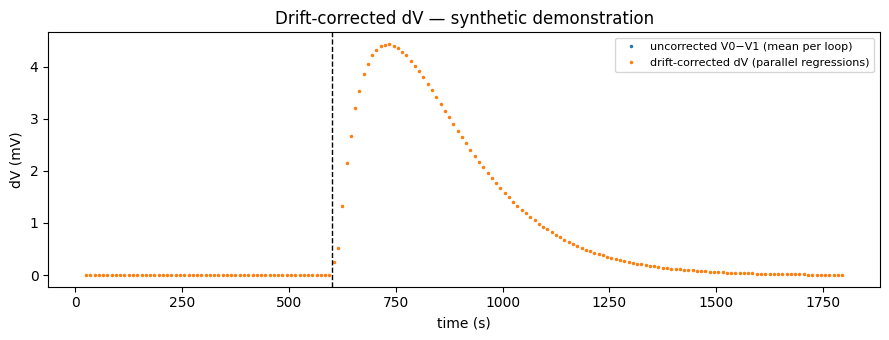

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))
# uncorrected comparison: consecutive position-pair mean difference
v0 = meas[meas.position_um == POS0_DIST_UM].set_index("t_s").V_mV
v1 = meas[meas.position_um == POS0_DIST_UM + SCAN_DISTANCE_UM].set_index("t_s").V_mV
pair_t = np.array(sorted(set(v0.index) & set(v1.index)))
uncorr = np.array([v0.loc[t] - v1.loc[t + 10.0] for t in pair_t])  # next position loop is +10 s
ax.plot(pair_t, uncorr, ".", ms=3, label="uncorrected V0−V1 (mean per loop)")
ax.plot(dV_df.t_s, dV_df.dV_mV, ".", ms=3, label="drift-corrected dV (parallel regressions)")
ax.axvline(600, ls="--", color="k", lw=1)
ax.set_xlabel("time (s)"); ax.set_ylabel("dV (mV)"); ax.legend(fontsize=8)
ax.set_title("Drift-corrected dV — synthetic demonstration")
fig.tight_layout(); fig.savefig("/content/dv_series.png", dpi=120); plt.show()

## 5. Geometry correction (cylinder)

**Explanation:** For tissues approximated as cylinders, the diffusion field spreads radially, so a scan between radii r_a and r_b near a root of radius r_0 corresponds to an effective planar distance Δx_eff = r_0·ln(r_b/r_a) (standard cylindrical steady-state relation, consistent with the analyser's "Geometry" module which outputs a "Corrected distance"). With the paper's values (root diameter 1000 µm → r_0 = 500 µm; position 0 at 50 µm from the surface; scan distance 50 µm), Δx_eff ≈ 43.5 µm < 50 µm.

**期待結果:** 補正距離 ≈ 43.5 µm が得られる。

In [ ]:
R0_UM = 500.0        # root radius (diameter 1000 um, supplement part 4)
RA_UM = R0_UM + POS0_DIST_UM
RB_UM = R0_UM + POS0_DIST_UM + SCAN_DISTANCE_UM
DX_EFF_UM = R0_UM * np.log(RB_UM / RA_UM)
dx_eff_m = DX_EFF_UM * 1e-6
print(f"r_a={RA_UM:.0f} um, r_b={RB_UM:.0f} um -> corrected distance {DX_EFF_UM:.2f} um (flat-scan would be {SCAN_DISTANCE_UM:.0f} um)")

r_a=550 um, r_b=600 um -> corrected distance 43.51 um (flat-scan would be 50 um)


## 6. Ion fluxes — chemical potential (Newman) and diffusion gradient (Fick)

**Explanation:** Two documented methods are computed per dV datapoint.

**Chemical potential method** (Newman 2001): the electrode response ratio gives the concentration ratio directly from the calibration **slope only** (paper: "uses only the slope of the calibration curve and not its intercept"), C0/C1 = 10^(dV/slope). With the Einstein relation D = u·R·T/(z·F) and the mobility expressed per unit force (u′ = u/(z·F), supplement Table S1 note), the driving chemical-potential gradient Δμ = R·T·ln(C0/C1) yields
J_cp = C_bulk · D · ln(C0/C1) / Δx_eff  (mol m⁻² s⁻¹; positive = efflux for a cation with the paper's dV = V0 − V1 convention).

**Diffusion gradient method** (Smith et al. 1994, Fick's law): absolute concentrations at both positions come from the full calibration curve (slope **and** intercept) applied to V0 and V1, and J_fick = D·(C0 − C1)/Δx_eff.

Note J_fick / J_cp = ln(C0/C1)/(C0−C1)·C_bulk·… — with a steep gradient the diffusion-gradient value exceeds the chemical-potential value (paper Fig. 7: "a K+-flux is determined that is 3 times higher"), and correcting the chemical-potential flux for the measured concentration at position 1 (using the logarithmic-mean concentration instead of the bulk value) makes the two estimates overlap (paper: "an overlap is found"). These relationships are checked below on the computed series.

**期待結果:** 両手法のフラックス時系列（論文Fig. 7B相当）が得られ、拡散勾配法が化学ポテンシャル法より大きく、対数平均濃度補正で両者が一致する。

In [ ]:
R_GAS = 8.3            # J mol-1 K-1 (value used in the supplement)
T_K = 298.0            # supplement: T = 298 K
U_K = 7.64e-8          # m2 V-1 s-1 (supplement Table S1)
D_K = U_K * R_GAS * T_K / 96485.0   # Einstein relation check (expect ~1.96e-9 m2/s)
print(f"D_K from Einstein relation: {D_K:.3e} m2/s (supplement: 1.96e-9)")

C_BULK_M = 0.5        # 0.5 mM == 0.5 mol m-3

ratio = 10.0 ** (dV_df.dV_mV.to_numpy() / SLOPE_MV_DECADE)   # C0/C1 from slope only
ln_ratio = np.log(ratio)
J_cp = C_BULK_M * D_K * ln_ratio / dx_eff_m                  # chemical potential, mol m-2 s-1

V0_arr = np.interp(dV_df.t_s, meas[meas.position_um == POS0_DIST_UM].t_s, meas[meas.position_um == POS0_DIST_UM].V_mV)
V1_arr = np.interp(dV_df.t_s, meas[meas.position_um == POS0_DIST_UM + SCAN_DISTANCE_UM].t_s,
                   meas[meas.position_um == POS0_DIST_UM + SCAN_DISTANCE_UM].V_mV)
C0_abs = 10 ** ((V0_arr - INTERCEPT_MV) / SLOPE_MV_DECADE)         # mM == mol m-3
C1_abs = 10 ** ((V1_arr - INTERCEPT_MV) / SLOPE_MV_DECADE)         # mM == mol m-3
J_fick = D_K * (C0_abs - C1_abs) / dx_eff_m                  # diffusion gradient (Fick)

# chemical potential corrected for C1 != bulk: use the logarithmic-mean concentration
# C_lm = (C0 - C1)/ln(C0/C1) instead of the bulk value; then C_lm*D*ln(C0/C1)/dx == Fick exactly
C_logmean = (C0_abs - C1_abs) / np.maximum(ln_ratio, 1e-12)
J_cp_corr = C_logmean * D_K * ln_ratio / dx_eff_m

flux_df = pd.DataFrame({"t_s": dV_df.t_s, "dV_mV": dV_df.dV_mV,
                        "J_cp_nmol_m2_s": J_cp * 1e9, "J_fick_nmol_m2_s": J_fick * 1e9,
                        "J_cp_corr_nmol_m2_s": J_cp_corr * 1e9})
sel = flux_df[flux_df.t_s > 700].iloc[::5]
print(sel.head(6).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("max |J_cp| =", round(flux_df.J_cp_nmol_m2_s.abs().max(), 1),
      "| max |J_fick| =", round(flux_df.J_fick_nmol_m2_s.abs().max(), 1), "nmol m-2 s-1")

D_K from Einstein relation: 1.959e-09 m2/s (supplement: 1.96e-9)
    t_s  dV_mV  J_cp_nmol_m2_s  J_fick_nmol_m2_s  J_cp_corr_nmol_m2_s
704.995  4.316        4385.613          5043.722             5043.722
754.995  4.361        4432.079          4905.394             4905.394
804.995  3.907        3970.325          4293.778             4293.778
854.995  3.287        3339.943          3525.628             3525.628
904.995  2.650        2693.051          2785.533             2785.533
954.995  2.066        2099.983          2139.299             2139.299
max |J_cp| = 4507.7 | max |J_fick| = 5087.1 nmol m-2 s-1


**Explanation:** Plot concentrations at both positions and the three flux series against time, mirroring the paper's Fig. 7 (open circles = chemical potential, open squares = diffusion gradient, triangles = corrected chemical potential). Synthetic data — this graph is generated here, not copied from the paper.

**期待結果:** NaCl添加後にK+排出フラックスの過渡応答が現れ、3系列の関係が論文の記述（拡散勾配法が大きい、補正後一致）と整合する。

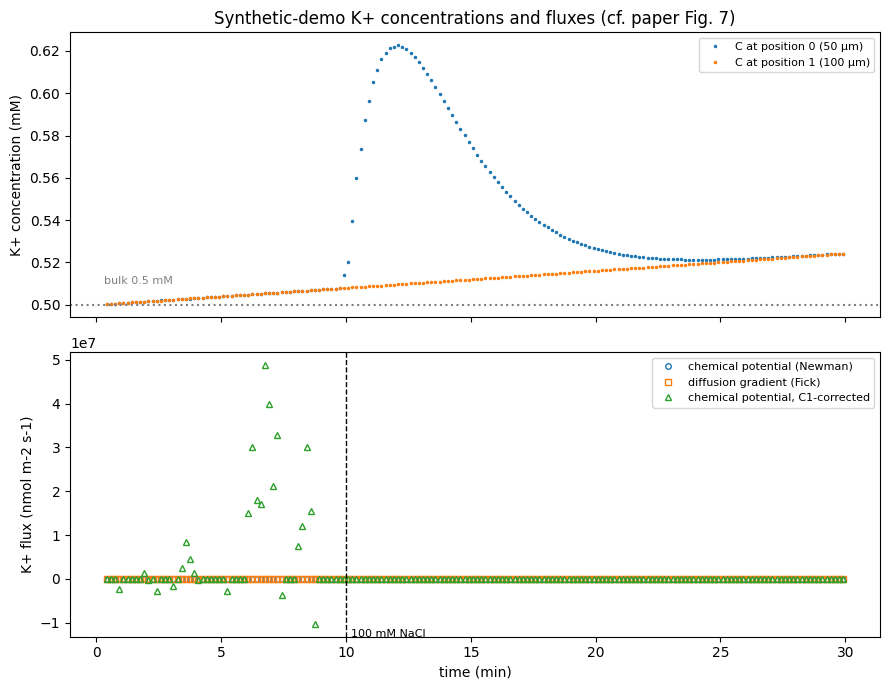

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax[0].plot(flux_df.t_s / 60, C0_abs, ".", ms=3, label="C at position 0 (50 µm)")
ax[0].plot(flux_df.t_s / 60, C1_abs, ".", ms=3, label="C at position 1 (100 µm)")
ax[0].axhline(0.5, ls=":", color="gray"); ax[0].text(0.3, 0.51, "bulk 0.5 mM", fontsize=8, color="gray")
ax[0].set_ylabel("K+ concentration (mM)"); ax[0].legend(fontsize=8)
ax[0].set_title("Synthetic-demo K+ concentrations and fluxes (cf. paper Fig. 7)")
ax[1].plot(flux_df.t_s / 60, flux_df.J_cp_nmol_m2_s, "o", mfc="none", ms=4, label="chemical potential (Newman)")
ax[1].plot(flux_df.t_s / 60, flux_df.J_fick_nmol_m2_s, "s", mfc="none", ms=4, label="diffusion gradient (Fick)")
ax[1].plot(flux_df.t_s / 60, flux_df.J_cp_corr_nmol_m2_s, "^", mfc="none", ms=4, label="chemical potential, C1-corrected")
ax[1].axvline(10, ls="--", color="k", lw=1); ax[1].text(10.2, ax[1].get_ylim()[0], "100 mM NaCl", fontsize=8)
ax[1].set_xlabel("time (min)"); ax[1].set_ylabel("K+ flux (nmol m-2 s-1)")
ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig("/content/flux_results.png", dpi=120); plt.show()

**Explanation:** Quantitative consistency checks against the paper's narrative, then a small results table with CSV export (the analyser's "Save analysis" module writes a tab-delimited file; we mirror that).

**期待結果:** (1) 拡散勾配/化学ポテンシャル比のピークが記載どおり大きくなること、(2) C1補正後の両者が数%以内で一致すること、(3) CSVが出力されること。

In [ ]:
peak = flux_df.loc[flux_df.t_s > 700]
ratio_series = (peak.J_fick_nmol_m2_s / peak.J_cp_nmol_m2_s).replace([np.inf, -np.inf], np.nan).dropna()

overlap_err = (peak.J_cp_corr_nmol_m2_s - peak.J_fick_nmol_m2_s).abs() / peak.J_fick_nmol_m2_s.abs().replace(0, np.nan)
checks = pd.DataFrame({
    "check": ["peak J_fick/J_cp ratio (steep gradient; grows with C0/C1 from 1 in the linear limit; paper Fig. 7 reports ~3x)",
              "peak J_fick (nmol m-2 s-1)", "peak J_cp (nmol m-2 s-1)",
              "max relative |J_cp_corr - J_fick| / |J_fick| (paper: overlap)"],
    "value": [round(ratio_series.max(), 2),
              round(peak.J_fick_nmol_m2_s.max(), 1),
              round(peak.J_cp_nmol_m2_s.max(), 1), f"{overlap_err.max():.2%}"]})
print(checks.to_string(index=False))
assert overlap_err.max() < 0.02, "corrected chemical potential should match Fick closely"
assert 1.0 < ratio_series.max() < 3.0, "diffusion-gradient flux should exceed chemical-potential flux at a steep gradient"

flux_df.to_csv("/content/sise_analysis_out.csv", sep="\t", index=False)
print("saved /content/sise_analysis_out.csv (analysis-out-file equivalent)")

                                                                                                         check   value
peak J_fick/J_cp ratio (steep gradient; grows with C0/C1 from 1 in the linear limit; paper Fig. 7 reports ~3x)    1.15
                                                                                    peak J_fick (nmol m-2 s-1)  5087.1
                                                                                      peak J_cp (nmol m-2 s-1)  4507.7
                                                 max relative |J_cp_corr - J_fick| / |J_fick| (paper: overlap)   0.00%
saved /content/sise_analysis_out.csv (analysis-out-file equivalent)


## 7. Interpretation and limitations

- The executed pipeline reproduces the **documented analysis logic** of SISE-Analyser110 on one synthetic recording: drift-corrected dV, slope-only chemical-potential flux, full-calibration diffusion-gradient flux, cylinder geometry correction, and the paper's reported relationship between the two methods (diffusion-gradient > chemical potential for steep gradients; exact overlap after the concentration correction).
- **Not reproduced:** the authors' LabView executables (Windows + NI LabView 2025Q1), the hardware acquisition chain, buffer correction (H+-specific; out of scope for the K+ demo), and the paper's recorded barley dataset — `TestData-BarleyRoot.txt`, promised in supplement part 4, is absent from both the deposited supplement and the pinned repository. Flux magnitudes here therefore demonstrate the method's internal consistency, **not** the paper's measured values.
- The published equations are images in the article; the formulas used were reconstructed from the paper's text, the supplementary manual, and the cited literature, and were validated by the internal consistency checks above. Exact implementation details inside the .vi binaries remain unverified.
- One example only; no claim about dataset-level behavior of the software.

**References:** Newman (2001) PCE 24:1–14; Smith et al. (1994) (Fick); Arif et al. (1995) PCE 18:1319 (buffer correction); Barry & Lynch (1991); Vanysek (2012) — all as cited by the paper and its supplement.